# foundations/03: External Input Protocols

This notebook demonstrates the external input system end-to-end. External inputs model experimental protocols (microfluidic ligand pulses, optogenetic stimulation, etc.) as **pseudo-species** whose dynamics are prescribed by a `PulseSchedule` rather than CRN kinetics.

**Key design invariant:** the same CRN with different input protocols produces the same `CRNContext` from the encoder — the protocol is experiment-level, not network-level.

**Contents:**
1. Pulse Schedule Visualization
2. Birth-Death with External Input
3. Toggle Switch with External Input
4. Negative Autoregulation with External Perturbation
5. Random Protocol for Training

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

from _shared.plotting import (
    setup_style, plot_trajectory_ensemble, plot_input_protocol, plot_input_and_response,
)

setup_style()

import numpy as np
import torch
import matplotlib.pyplot as plt

from crn_surrogate.crn import (
    CRN,
    Reaction,
    InputProtocol,
    PulseSchedule,
    PulseEvent,
    EMPTY_PROTOCOL,
    constant_input,
    single_pulse,
    repeated_pulse,
    step_sequence,
    random_protocol,
    random_input_protocol,
)
from crn_surrogate.crn.propensities import mass_action, hill_repression, constant_rate
from crn_surrogate.simulation import GillespieSSA, Trajectory

ssa = GillespieSSA()

## 1. Pulse Schedule Visualization

Four factory functions build `PulseSchedule` objects from common experimental patterns. Each schedule is evaluated over a dense time grid using `evaluate_array`.

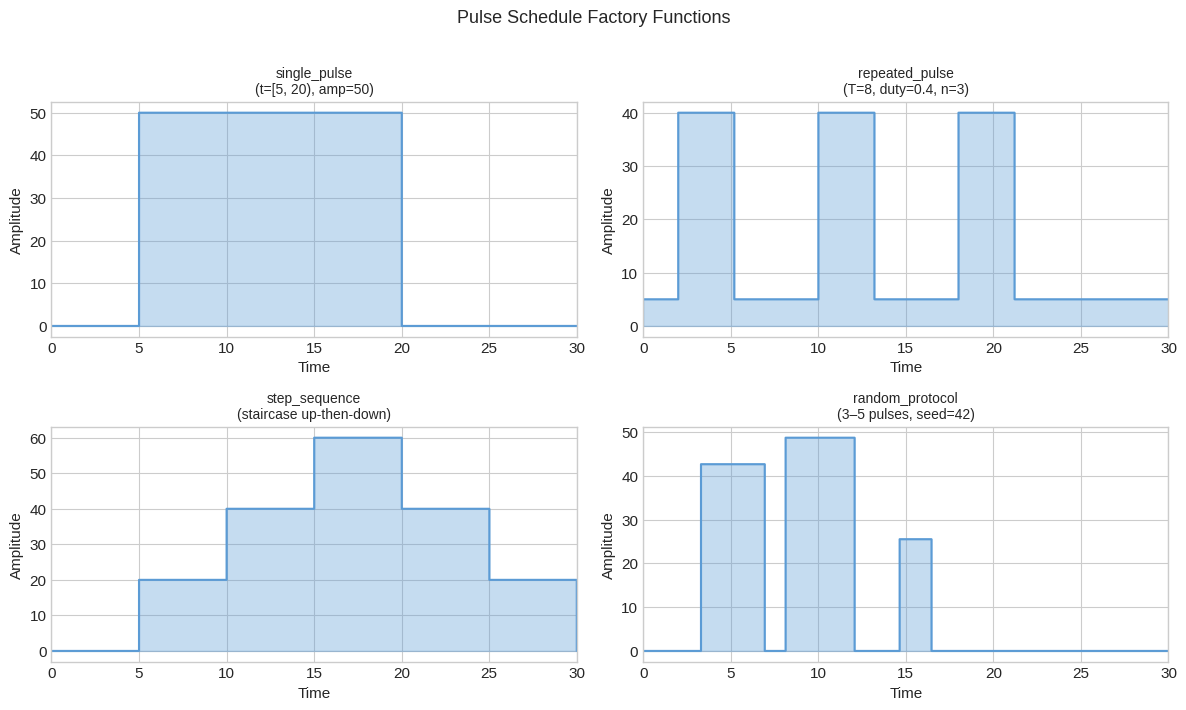

In [2]:
t_max_demo = 30.0
t_grid = np.linspace(0.0, t_max_demo, 3000)

schedules = [
    (
        single_pulse(t_start=5.0, t_end=20.0, amplitude=50.0, baseline=0.0),
        "single_pulse\n(t=[5, 20), amp=50)",
    ),
    (
        repeated_pulse(period=8.0, duty_cycle=0.4, amplitude=40.0, n_pulses=3, t_start=2.0, baseline=5.0),
        "repeated_pulse\n(T=8, duty=0.4, n=3)",
    ),
    (
        step_sequence(
            times=[0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0],
            amplitudes=[0.0, 20.0, 40.0, 60.0, 40.0, 20.0],
            baseline=0.0,
        ),
        "step_sequence\n(staircase up-then-down)",
    ),
    (
        random_protocol(t_max=t_max_demo, n_pulses_range=(3, 5), duration_range=(1.5, 4.0),
                        amplitude_range=(10.0, 80.0), gap_range=(1.0, 3.0),
                        rng=np.random.default_rng(42)),
        "random_protocol\n(3\u20135 pulses, seed=42)",
    ),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.flatten()

for ax, (sched, title) in zip(axes, schedules):
    vals = sched.evaluate_array(t_grid)
    plot_input_protocol(ax, t_grid, vals)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Time")
    ax.set_ylabel("Amplitude")
    ax.set_xlim(0, t_max_demo)

fig.suptitle("Pulse Schedule Factory Functions", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 2. Birth-Death with External Input

We construct a modified birth-death process where the birth rate is driven by an external inducer species $I$:

$$\text{Birth: } \emptyset \xrightarrow{k \cdot I} A \qquad \text{Death: } A \xrightarrow{k_{\deg}} \emptyset$$

The inducer $I$ is an external pseudo-species — it appears in the dependency graph and modulates the birth propensity, but its own dynamics are prescribed by an `InputProtocol`. Its net stoichiometric change in every reaction is zero.

**Species layout:** index 0 = $A$ (internal), index 1 = $I$ (external inducer).

In [3]:
k_birth = 0.5
k_deg   = 0.3

birth_propensity = mass_action(
    rate_constant=k_birth,
    reactant_stoichiometry=torch.tensor([0.0, 1.0]),  # depends on I only
)
death_propensity = mass_action(
    rate_constant=k_deg,
    reactant_stoichiometry=torch.tensor([1.0, 0.0]),  # depends on A only
)

crn_bd_ext = CRN(
    reactions=[
        Reaction(stoichiometry=torch.tensor([1.0, 0.0]), propensity=birth_propensity),
        Reaction(stoichiometry=torch.tensor([-1.0, 0.0]), propensity=death_propensity),
    ],
    species_names=["A", "I"],
    external_species=frozenset({1}),
)
print(crn_bd_ext)
print(f"External species: {crn_bd_ext.external_species}")

CRN(n_species=2, n_reactions=2, species=('A', 'I'))
External species: frozenset({1})


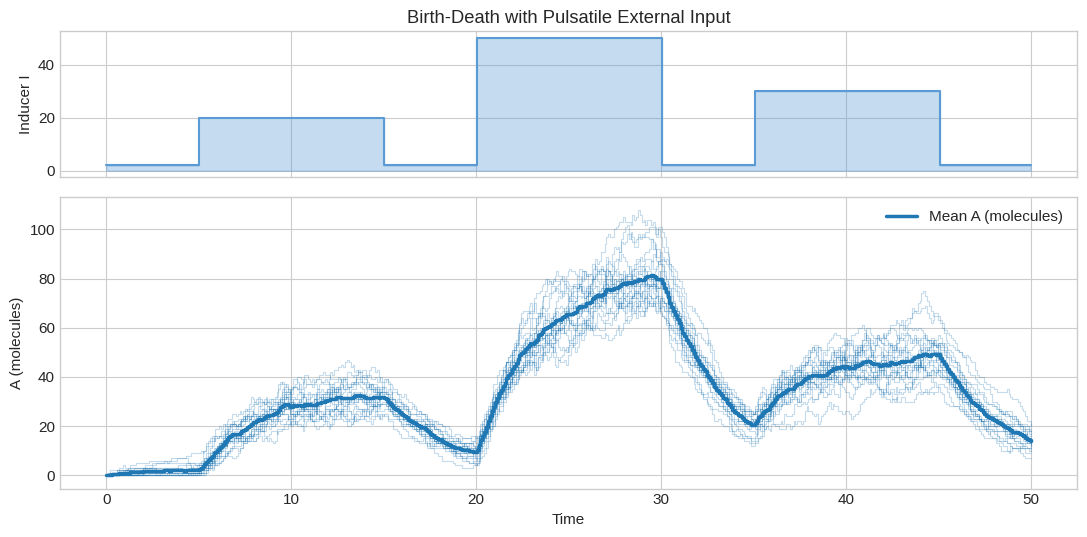

Expected E[A] per pulse amplitude: 33.3, 83.3, 50.0


In [4]:
# Three pulses of increasing amplitude
inducer_schedule = PulseSchedule(
    events=(
        PulseEvent(t_start=5.0,  t_end=15.0, amplitude=20.0),
        PulseEvent(t_start=20.0, t_end=30.0, amplitude=50.0),
        PulseEvent(t_start=35.0, t_end=45.0, amplitude=30.0),
    ),
    baseline=2.0,
)
protocol_bd = InputProtocol(schedules={1: inducer_schedule})

t_max_bd = 50.0
t_plot = np.linspace(0.0, t_max_bd, 500)
inducer_vals = inducer_schedule.evaluate_array(t_plot)

states_bd = Trajectory.stack_on_grid(
    ssa.simulate_batch(
        stoichiometry=crn_bd_ext.stoichiometry_matrix,
        propensity_fn=crn_bd_ext.evaluate_propensities,
        initial_state=torch.tensor([0.0, 0.0]),
        t_max=t_max_bd,
        n_trajectories=20,
        input_protocol=protocol_bd,
        external_species=crn_bd_ext.external_species,
        n_workers=8,
    ),
    torch.tensor(t_plot),
).numpy()

fig = plot_input_and_response(
    t_grid=t_plot,
    input_values=inducer_vals,
    states=states_bd,
    species_indices=[0],
    species_names=["A (molecules)"],
    input_label="Inducer I",
    title="Birth-Death with Pulsatile External Input",
)
plt.show()

print(f"Expected E[A] per pulse amplitude: {20*k_birth/k_deg:.1f}, {50*k_birth/k_deg:.1f}, {30*k_birth/k_deg:.1f}")

## 3. Toggle Switch with External Input

A bistable toggle switch has two mutually repressing genes. We add an external signal that **activates** each gene's production independently, allowing the protocol to bias which state dominates.

**Species layout:** index 0 = $A$, index 1 = $B$, index 2 = $S_1$ (external, boosts A), index 3 = $S_2$ (external, boosts B).

In [5]:
k_max   = 50.0
k_half  = 30.0
n_hill  = 3.0
k_deg   = 0.2
k_boost = 0.8

crn_toggle = CRN(
    reactions=[
        Reaction(
            stoichiometry=torch.tensor([1.0, 0.0, 0.0, 0.0]),
            propensity=hill_repression(k_max=k_max, k_half=k_half, hill_coefficient=n_hill, species_index=1),
        ),
        Reaction(
            stoichiometry=torch.tensor([1.0, 0.0, 0.0, 0.0]),
            propensity=mass_action(rate_constant=k_boost,
                                   reactant_stoichiometry=torch.tensor([0.0, 0.0, 1.0, 0.0])),
        ),
        Reaction(
            stoichiometry=torch.tensor([-1.0, 0.0, 0.0, 0.0]),
            propensity=mass_action(rate_constant=k_deg,
                                   reactant_stoichiometry=torch.tensor([1.0, 0.0, 0.0, 0.0])),
        ),
        Reaction(
            stoichiometry=torch.tensor([0.0, 1.0, 0.0, 0.0]),
            propensity=hill_repression(k_max=k_max, k_half=k_half, hill_coefficient=n_hill, species_index=0),
        ),
        Reaction(
            stoichiometry=torch.tensor([0.0, 1.0, 0.0, 0.0]),
            propensity=mass_action(rate_constant=k_boost,
                                   reactant_stoichiometry=torch.tensor([0.0, 0.0, 0.0, 1.0])),
        ),
        Reaction(
            stoichiometry=torch.tensor([0.0, -1.0, 0.0, 0.0]),
            propensity=mass_action(rate_constant=k_deg,
                                   reactant_stoichiometry=torch.tensor([0.0, 1.0, 0.0, 0.0])),
        ),
    ],
    species_names=["A", "B", "S1", "S2"],
    external_species=frozenset({2, 3}),
)
print(crn_toggle)

CRN(n_species=4, n_reactions=6, species=('A', 'B', 'S1', 'S2'))


In [ ]:
t_max_toggle = 240.0

signal_schedule_2 = repeated_pulse(
    period=120.0, duty_cycle=0.25, amplitude=20.0, n_pulses=2, t_start=70.0, baseline=0.0,
)
signal_schedule_3 = repeated_pulse(
    period=120.0, duty_cycle=0.25, amplitude=20.0, n_pulses=2, t_start=10.0, baseline=0.0,
)
protocol_toggle = InputProtocol(schedules={2: signal_schedule_2, 3: signal_schedule_3})

t_plot_toggle = np.linspace(0.0, t_max_toggle, 1200)
signal_vals_2 = signal_schedule_2.evaluate_array(t_plot_toggle)
signal_vals_3 = signal_schedule_3.evaluate_array(t_plot_toggle)

states_toggle = Trajectory.stack_on_grid(
    ssa.simulate_batch(
        stoichiometry=crn_toggle.stoichiometry_matrix,
        propensity_fn=crn_toggle.evaluate_propensities,
        initial_state=torch.zeros(4),
        t_max=t_max_toggle,
        n_trajectories=20,
        input_protocol=protocol_toggle,
        external_species=crn_toggle.external_species,
        n_workers=8,
    ),
    torch.tensor(t_plot_toggle),
).numpy()

fig, (ax_in, ax_A, ax_B) = plt.subplots(
    3, 1, figsize=(12, 8), sharex=True,
    gridspec_kw={"height_ratios": [1, 2, 2]},
)

plot_input_protocol(ax_in, t_plot_toggle, signal_vals_2, color="#5B9BD5", label="S1 (boosts A)")
plot_input_protocol(ax_in, t_plot_toggle, signal_vals_3, color="tab:orange", label="S2 (boosts B)")
ax_in.set_ylabel("Signal S")
ax_in.set_title("Toggle Switch: External Signal Biases State")
ax_in.legend(fontsize=9)

plot_trajectory_ensemble(ax_A, t_plot_toggle, states_toggle, species_idx=0,
                         color="tab:blue", label="Mean A")
ax_A.set_ylabel("Gene A")
ax_A.legend(loc="upper right")

plot_trajectory_ensemble(ax_B, t_plot_toggle, states_toggle, species_idx=1,
                         color="tab:orange", label="Mean B")
ax_B.set_ylabel("Gene B")
ax_B.set_xlabel("Time")
ax_B.legend(loc="upper right")

plt.tight_layout()
plt.show()

## 4. Negative Autoregulation with External Perturbation

Negative autoregulation (NAR) is a noise-suppression motif: a gene $A$ represses its own transcription, pulling the mean to a well-defined set point and reducing variance.

We add an external input $E$ that contributes a **basal production term** alongside the autoregulated production. A staircase input shows dose-response: higher $E$ shifts the steady state up, but the NAR feedback maintains noise suppression at each step.

**Species layout:** index 0 = $A$ (internal), index 1 = $E$ (external).

In [ ]:
k_max_nar  = 30.0
k_half_nar = 20.0
n_nar      = 2.0
k_ext_nar  = 0.5
k_deg_nar  = 0.3

crn_nar = CRN(
    reactions=[
        Reaction(
            stoichiometry=torch.tensor([1.0, 0.0]),
            propensity=hill_repression(
                k_max=k_max_nar, k_half=k_half_nar, hill_coefficient=n_nar, species_index=0,
            ),
        ),
        Reaction(
            stoichiometry=torch.tensor([1.0, 0.0]),
            propensity=mass_action(
                rate_constant=k_ext_nar,
                reactant_stoichiometry=torch.tensor([0.0, 1.0]),
            ),
        ),
        Reaction(
            stoichiometry=torch.tensor([-1.0, 0.0]),
            propensity=mass_action(
                rate_constant=k_deg_nar,
                reactant_stoichiometry=torch.tensor([1.0, 0.0]),
            ),
        ),
    ],
    species_names=["A", "E"],
    external_species=frozenset({1}),
)
print(crn_nar)

In [ ]:
t_max_nar = 200.0
step_times = [0.0, 40.0, 80.0, 120.0, 160.0, 200.0]
step_amps  = [0.0, 10.0, 20.0, 40.0, 60.0]

ext_schedule_nar = step_sequence(times=step_times, amplitudes=step_amps, baseline=0.0)
protocol_nar = InputProtocol(schedules={1: ext_schedule_nar})

t_plot_nar = np.linspace(0.0, t_max_nar, 1000)
ext_vals_nar = ext_schedule_nar.evaluate_array(t_plot_nar)

states_nar = Trajectory.stack_on_grid(
    ssa.simulate_batch(
        stoichiometry=crn_nar.stoichiometry_matrix,
        propensity_fn=crn_nar.evaluate_propensities,
        initial_state=torch.zeros(2),
        t_max=t_max_nar,
        n_trajectories=20,
        input_protocol=protocol_nar,
        external_species=crn_nar.external_species,
        n_workers=8,
    ),
    torch.tensor(t_plot_nar),
).numpy()

fig = plot_input_and_response(
    t_grid=t_plot_nar,
    input_values=ext_vals_nar,
    states=states_nar,
    species_indices=[0],
    species_names=["Gene A (molecules)"],
    input_label="External E",
    title="Negative Autoregulation: Dose-Response with Staircase Input",
)
plt.show()

print("Negative feedback keeps variance low at each plateau.")
print("Higher external input E shifts the steady state upward (dose-response).")

## 5. Random Protocol for Training

`random_input_protocol` generates diverse `InputProtocol` objects for training data diversity. Each call with a different random seed produces an independent pulse train for each input species.

Below we generate 6 random single-species protocols and display them in a 2×3 grid, as they would appear in a training batch.

In [ ]:
t_max_rand = 50.0
t_grid_rand = np.linspace(0.0, t_max_rand, 2000)

rng_seeds = [0, 7, 42, 99, 137, 256]

fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharey=True)
axes = axes.flatten()

for ax, seed in zip(axes, rng_seeds):
    protocol = random_input_protocol(
        input_species_indices=[0],
        t_max=t_max_rand,
        n_pulses_range=(2, 6),
        duration_range=(2.0, 8.0),
        amplitude_range=(5.0, 100.0),
        gap_range=(1.0, 5.0),
        baseline=0.0,
        rng=np.random.default_rng(seed),
    )
    sched = protocol.schedules[0]
    vals = sched.evaluate_array(t_grid_rand)
    n_pulses = len(sched.events)

    plot_input_protocol(ax, t_grid_rand, vals, color="#C55A11")
    ax.set_title(f"seed={seed}, n_pulses={n_pulses}", fontsize=9)
    ax.set_xlabel("Time", fontsize=9)
    ax.set_xlim(0, t_max_rand)

axes[0].set_ylabel("Amplitude")
axes[3].set_ylabel("Amplitude")

fig.suptitle(
    "random_input_protocol \u2014 6 Independent Samples\n"
    "(2\u20136 pulses, duration 2\u20138 t.u., amplitude 5\u2013100, log-uniform)",
    fontsize=11,
)
plt.tight_layout()
plt.show()

print("""
Training data generation:
  - For each (CRN, params) sample, draw a fresh random_input_protocol.
  - Simulate M SSA trajectories under that protocol.
  - The CRNTensorRepr encodes network structure + external connectivity.
  - The InputProtocol is passed to the Gillespie simulator only.
  - At inference time, any new protocol can be applied to the same encoder output.
""")

## Summary

| Feature | API |
|---|---|
| Define a pulse train | `single_pulse`, `repeated_pulse`, `step_sequence`, `random_protocol` |
| Bundle schedules for multiple species | `InputProtocol(schedules={idx: schedule, ...})` |
| Mark a species as external in the CRN | `CRN(..., external_species=frozenset({idx}))` |
| Simulate with input | `ssa.simulate(..., input_protocol=protocol, external_species=crn.external_species)` |
| Encoder boundary | `CRNTensorRepr.is_external` — external species get no reaction-to-species messages |

The input protocol never enters `crn_to_tensor_repr`. The encoder sees only network structure; the protocol is consumed only by the simulator.